# EfficientSAM — Segmentación con prompts de YOLOv9

Pipeline:
1. YOLOv9 detecta `rubber_strip` y `cut_edge` → bounding boxes
2. EfficientSAM recibe esas bboxes como prompts → máscaras pixel a pixel
3. Visualización y métricas IoU

## 1. Instalación

In [ ]:
%pip install git+https://github.com/yformer/EfficientSAM.git --quiet
%pip install ultralytics --quiet
print('Instalación OK')

## 2. Cargar modelos

In [6]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

# --- YOLOv9 ---
YOLO_WEIGHTS = "runs/data/runs/michelin_v1-2/weights/best.pt"
yolo = YOLO(YOLO_WEIGHTS)
CLASS_NAMES = {0: "cut_edge", 1: "qr_code", 2: "rubber_strip"}

# --- EfficientSAM (ViT-Tiny) con pesos preentrenados ---
# Descarga manual: https://github.com/yformer/EfficientSAM/blob/main/weights/efficient_sam_vitt.pt
# Guarda el archivo en la misma carpeta que este notebook
WEIGHTS_PATH = Path("efficient_sam_vitt.pt")
assert WEIGHTS_PATH.exists(), f"Pesos no encontrados en {WEIGHTS_PATH.resolve()}"

from efficient_sam.efficient_sam import build_efficient_sam

sam = build_efficient_sam(
    encoder_patch_embed_dim=192,
    encoder_num_heads=3,
    checkpoint=str(WEIGHTS_PATH),
)
sam.eval()

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
sam = sam.to(DEVICE)

print(f"YOLO y EfficientSAM cargados en {DEVICE}")

YOLO y EfficientSAM cargados en cuda


## 3. Función de segmentación

In [7]:
def run_efficient_sam(sam_model, image_np, box_xyxy):
    """
    Usa las esquinas de la bbox como prompt directo (labels 2 y 3).
    Esto reemplaza el punto central y mejora el IoU significativamente.
    """
    H, W = image_np.shape[:2]
    x1, y1, x2, y2 = [int(v) for v in box_xyxy]

    pad = 15
    x1p = max(0, x1 - pad);  y1p = max(0, y1 - pad)
    x2p = min(W, x2 + pad);  y2p = min(H, y2 + pad)
    crop = image_np[y1p:y2p, x1p:x2p]

    # Coordenadas de la bbox relativas al recorte
    bx1 = float(x1 - x1p);  by1 = float(y1 - y1p)
    bx2 = float(x2 - x1p);  by2 = float(y2 - y1p)

    img_tensor = torch.from_numpy(crop).permute(2, 0, 1).float() / 255.0
    img_tensor = img_tensor.unsqueeze(0).to(DEVICE)

    # Labels 2/3: esquinas top-left y bottom-right de la caja
    pts = torch.tensor([[[[bx1, by1], [bx2, by2]]]], dtype=torch.float32).to(DEVICE)
    lbl = torch.tensor([[[2, 3]]],                   dtype=torch.int32).to(DEVICE)

    with torch.no_grad():
        masks, scores = sam_model(img_tensor, pts, lbl)

    best      = scores[0, 0].argmax().item()
    crop_mask = masks[0, 0, best].cpu().numpy() > 0.5

    full_mask = np.zeros((H, W), dtype=bool)
    full_mask[y1p:y2p, x1p:x2p] = crop_mask
    return full_mask


def compute_iou(mask, box_xyxy, img_shape):
    """IoU entre mascara predicha y area de la bbox (ground truth aproximado)."""
    H, W = img_shape[:2]
    x1, y1, x2, y2 = map(int, box_xyxy)
    gt = np.zeros((H, W), dtype=bool)
    gt[y1:y2, x1:x2] = True
    intersection = (mask & gt).sum()
    union        = (mask | gt).sum()
    return float(intersection / union) if union > 0 else 0.0


print("Funciones listas.")

Funciones listas.


## 4. Test sobre una imagen

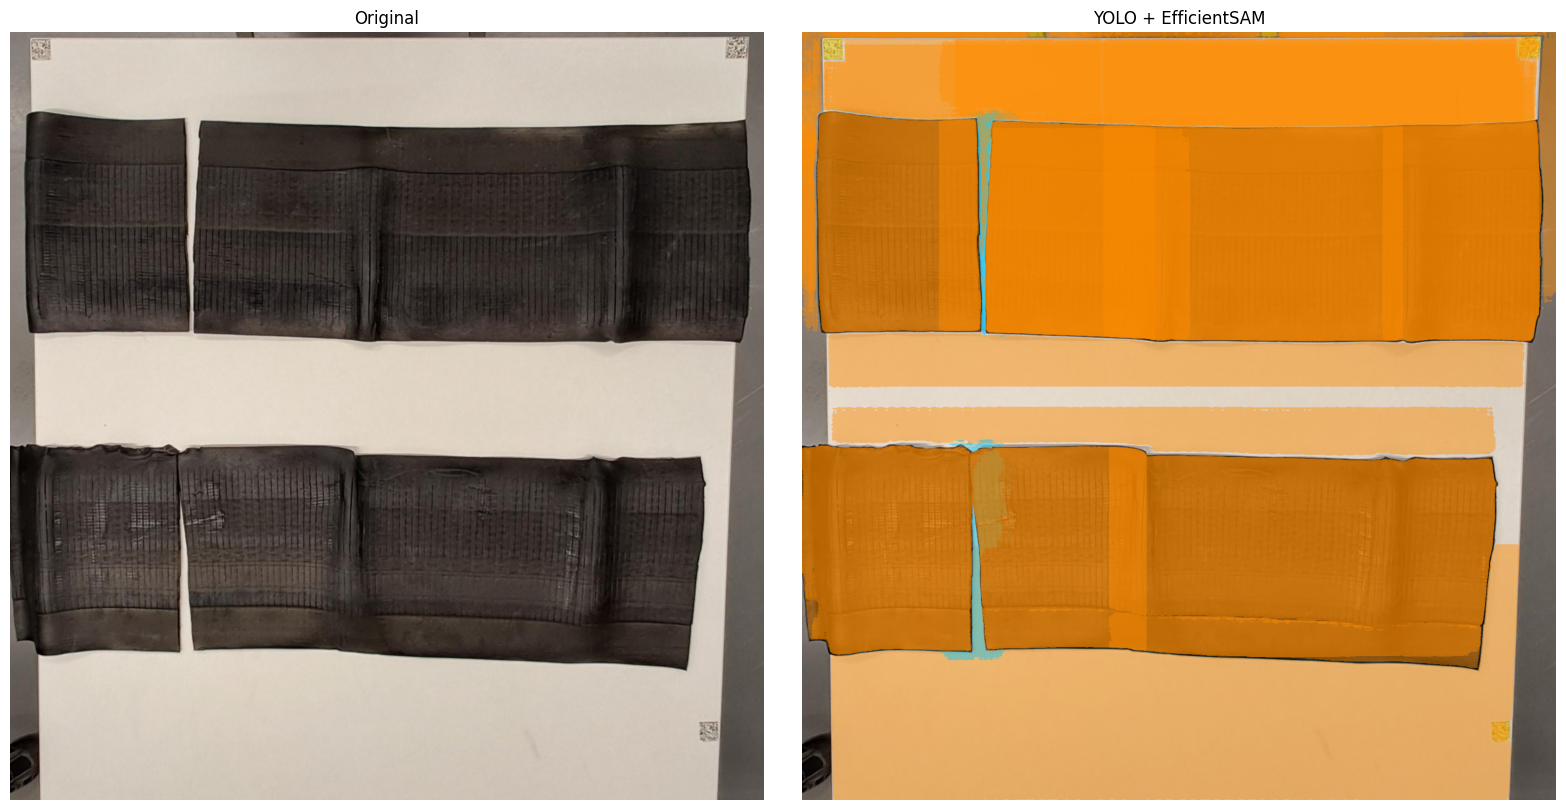

IoU por detección:
  rubber_strip: 0.323
  rubber_strip: 0.115
  rubber_strip: 0.884
  qr_code: 0.780
  qr_code: 0.817
  qr_code: 0.768
  rubber_strip: 0.897
  rubber_strip: 0.566
  cut_edge: 0.185
  rubber_strip: 0.068
  rubber_strip: 0.846
  cut_edge: 0.179
  rubber_strip: 0.068
  rubber_strip: 0.797
  rubber_strip: 0.033
  cut_edge: 0.281
  cut_edge: 0.114
  qr_code: 0.570
  rubber_strip: 0.884
  rubber_strip: 0.009
  rubber_strip: 0.779
  rubber_strip: 0.875
  qr_code: 0.527
  rubber_strip: 0.771
  rubber_strip: 0.780
  rubber_strip: 0.266
  rubber_strip: 0.934
  rubber_strip: 0.027


In [8]:
IMAGE_PATH = "../data/raw/multimedia_01.jpg"

img_bgr = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
H, W    = img_rgb.shape[:2]

# YOLOv9 → bboxes
preds = yolo(img_bgr, verbose=False)[0]

# Colores por clase
COLORS = {0: (0, 200, 255), 1: (255, 220, 0), 2: (255, 140, 0)}
ALPHA  = 0.45

overlay = img_rgb.copy().astype(np.float32)
iou_scores = []

for box in preds.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    cls  = int(box.cls[0])
    conf = float(box.conf[0])
    col  = COLORS.get(cls, (255, 255, 255))

    # EfficientSAM
    mask = run_efficient_sam(sam, img_rgb, [x1, y1, x2, y2])
    iou  = compute_iou(mask, [x1, y1, x2, y2], img_rgb.shape)
    iou_scores.append((CLASS_NAMES[cls], iou))

    # Pintar máscara en overlay
    colored = np.zeros_like(overlay)
    colored[mask] = col
    overlay = np.where(mask[:, :, None], overlay * (1 - ALPHA) + colored * ALPHA, overlay)

    # Bbox + label
    cv2.rectangle(overlay.astype(np.uint8), (x1, y1), (x2, y2), col, 2)
    cv2.putText(overlay.astype(np.uint8),
                f"{CLASS_NAMES[cls]} {conf:.2f} IoU:{iou:.2f}",
                (x1, y1 - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.55, col, 2)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(img_rgb);             axes[0].set_title("Original");     axes[0].axis('off')
axes[1].imshow(overlay.astype(np.uint8)); axes[1].set_title("YOLO + EfficientSAM"); axes[1].axis('off')
plt.tight_layout()
plt.show()

print("IoU por detección:")
for name, iou in iou_scores:
    print(f"  {name}: {iou:.3f}")

## 5. Evaluación IoU sobre todo el dataset

In [9]:
from collections import defaultdict

image_paths = sorted(Path("../data/raw").glob("*.jpg"))
print(f"Imágenes: {len(image_paths)}")

iou_per_class = defaultdict(list)

for img_path in image_paths:
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    preds = yolo(img_bgr, verbose=False)[0]

    for box in preds.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cls = int(box.cls[0])
        try:
            mask = run_efficient_sam(sam, img_rgb, [x1, y1, x2, y2])
            iou  = compute_iou(mask, [x1, y1, x2, y2], img_rgb.shape)
            iou_per_class[CLASS_NAMES[cls]].append(iou)
        except Exception as e:
            print(f"  [WARN] {img_path.name} cls={cls}: {e}")

print("\nIoU medio por clase:")
for cls_name, ious in sorted(iou_per_class.items()):
    print(f"  {cls_name}: {np.mean(ious):.3f}  (n={len(ious)})")

Imágenes: 22

IoU medio por clase:
  cut_edge: 0.141  (n=45)
  qr_code: 0.698  (n=77)
  rubber_strip: 0.436  (n=336)
